Loading: /kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S

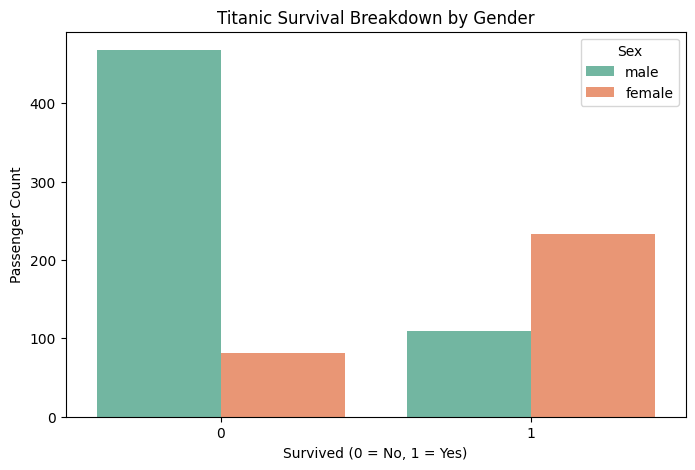

In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Locate and load the dataset automatically
df = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            print(f"Loading: {data_path}")
            df = pd.read_csv(data_path)
            break
    if df is not None:
        break

# 2. Inspect basic information
if df is not None:
    print("\n--- First 5 Rows ---")
    print(df.head())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    # 3. Visual chart
    plt.figure(figsize=(8, 5))
    if 'Survived' in df.columns and 'Sex' in df.columns:
        sns.countplot(data=df, x='Survived', hue='Sex', palette='Set2')
        plt.title('Titanic Survival Breakdown by Gender')
        plt.xlabel('Survived (0 = No, 1 = Yes)')
        plt.ylabel('Passenger Count')
        plt.show()
    else:
        sns.histplot(df.select_dtypes(include='number').iloc[:, 0], kde=True)
        plt.title('Distribution Analysis')
        plt.show()
else:
    print("No CSV file found in /kaggle/input. Make sure you attached the dataset!")